`pip install pandas numpy scikit-learn sentence-transformers hdbscan umap-learn matplotlib`

In [1]:
import pandas as pd

df = pd.read_csv("headlines_standardized.csv")

# sanity check
print(df["label"].value_counts())
df.head()

Series([], Name: count, dtype: int64)


,id,headline,country,label,headline_clean
0,1,0% salary hike even after great performance? E...,India,NaN,0 salary hike even after great performance emp...
1,2,Learjet 45: The jet Ajit Pawar took for his fi...,India,NaN,learjet 45 the jet ajit pawar took for his fin...
2,3,Lead the next wave of consumer businesses with...,India,NaN,lead the next wave of consumer businesses with...
3,4,CUET UG 2026 registration ends in two days: Ho...,India,NaN,cuet ug 2026 registration ends in two days how...
4,5,Employee who was denied WFH by boss due to los...,India,NaN,employee who was denied wfh by boss due to los...


In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df["headline_clean"].astype(str).tolist()
embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\91638\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\91638\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/93 [00:00<?, ?it/s]

In [3]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom"
)

clusters = clusterer.fit_predict(embeddings)
df["topic_cluster"] = clusters

print("Number of clusters:", len(set(clusters)) - (1 if -1 in clusters else 0))
print("Noise points:", (clusters == -1).sum())


Number of clusters: 2
Noise points: 2257


c:\Users\91638\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


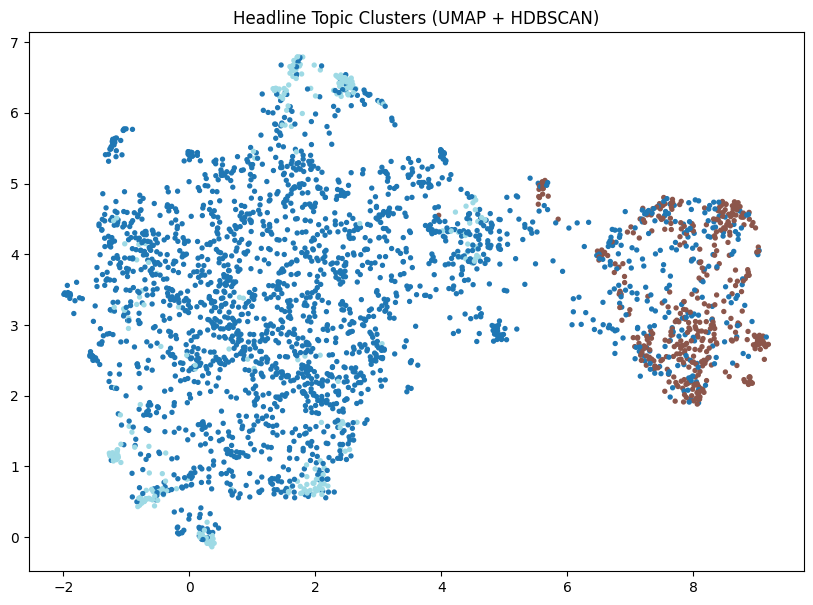

In [4]:
import umap
import matplotlib.pyplot as plt

umap_model = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)

emb_2d = umap_model.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=clusters,
    cmap="tab20",
    s=8
)
plt.title("Headline Topic Clusters (UMAP + HDBSCAN)")
plt.show()


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def extract_keywords(texts, top_n=5):
    tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
    X = tfidf.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).ravel()
    indices = scores.argsort()[-top_n:][::-1]
    return [tfidf.get_feature_names_out()[i] for i in indices]

topic_keywords = {}

for cluster_id in sorted(df["topic_cluster"].unique()):
    if cluster_id == -1:
        continue
    cluster_texts = df[df.topic_cluster == cluster_id]["headline_clean"]
    topic_keywords[cluster_id] = extract_keywords(cluster_texts)

topic_df = pd.DataFrame.from_dict(
    topic_keywords,
    orient="index",
    columns=[f"kw{i+1}" for i in range(5)]
)

print(topic_df.head())


     kw1       kw2       kw3        kw4     kw5
0     vs  transfer  football     injury  portal
1  trump  heatwave      live  australia     ice


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

print(dict(zip(le.classes_, le.transform(le.classes_))))


{nan: 0}


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    df["label_enc"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_enc"]
)


In [8]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

clf.fit(X_train, y_train)


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

In [9]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [10]:
import numpy as np

probabilities = clf.predict_proba(embeddings)

for i, label in enumerate(le.classes_):
    df[f"{label}_score"] = probabilities[:, i]


AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [ ]:
# Distribution of bias labels per topic
topic_bias_dist = (
    df[df.topic_cluster != -1]
    .groupby(["topic_cluster", "label"])
    .size()
    .unstack(fill_value=0)
)

print(topic_bias_dist.head())


In [ ]:
country_bias = (
    df[df.topic_cluster != -1]
    .groupby(["topic_cluster", "country", "label"])
    .size()
    .unstack(fill_value=0)
)

print(country_bias.head())


In [ ]:
topic_id = 3  # example

df[df.topic_cluster == topic_id][
    ["headline", "country", "label"]
].sample(10, random_state=42)
